In [1]:
from networks.BP_network import *
from networks.EWC_network import *
from networks.DFC_network import *
from networks.EFC_network import *
from src.dataloaders import *
from src.trainers import Trainer, TrainerDFCL
from src.utils import *
import matplotlib.animation as animation
from networks.activation_function import ScaledSigmoid

/cluster/raid/home/sschwartz/.conda/envs/DFC_project/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
config = {
        "layers": [784,200,200,200,10],
        "num_classes": 10,
        "lr": 1e-4, 
        "lr_fb": 1e-4, 
        "batch_size": 100,
        "batch_size_gen": 30000,
        "epochs": 20,
        "mode": "di",
        "num_workers": 0,
        "loss_fn": "ce",
        "optimizer": "Adam",
        "scheduler": "CosineAnnealingLR",
        "activation_fun": "Tanh",
        "device": "cuda",
        "output_dir": "./outputs",
        "seed": 1337,
        "taus": [0.02, 0.02, 0.02, 0.016, 0.01],
        "target_lr": 1,#1e-2,       # Updated to optimal value
        "alpha_di": 0.0017,        # 1/tau for tau=0.2
        "dt_di": 0.02,         # Time step
        "time_constant_ratio": 0.2,  # tau
        "tmax_di":10,
        "k_p": 2.0,             # Optimal for G=1, tau=0.2
        "eps": 1e-4,
        "save": True,
        "flatten_imgs": "default",
        "num_tasks": 2,
        "classes_per_task": 5,
        "setting": "full",
        "first_task_only": False,
}

config = dotdict(config)

In [3]:
# Load data
train_loader, test_loader = MNIST(config=config).get_dataloaders()

In [4]:
# Train model
model = DFCL_network_multilayer(config=config)

trainer = TrainerDFCL(model, train_loader, test_loader, config)
trainer.train()

[DFCL] Feedback connections initialized.
Training:
 - layers: [784, 200, 200, 200, 10]
 - num_classes: 10
 - lr: 0.0001
 - lr_fb: 0.0001
 - batch_size: 100
 - batch_size_gen: 30000
 - epochs: 20
 - mode: di
 - num_workers: 0
 - loss_fn: ce
 - optimizer: Adam
 - scheduler: CosineAnnealingLR
 - activation_fun: Tanh
 - device: cuda
 - output_dir: ./outputs
 - seed: 1337
 - taus: [0.02, 0.02, 0.02, 0.016, 0.01]
 - target_lr: 1
 - alpha_di: 0.0017
 - dt_di: 0.02
 - time_constant_ratio: 0.2
 - tmax_di: 10
 - k_p: 2.0
 - eps: 0.0001
 - save: True
 - flatten_imgs: default
 - num_tasks: 2
 - classes_per_task: 5
 - setting: full
 - first_task_only: False
 - in_channels: 1
 - model: DFCL_network

[TrainerDFCL] Created optimizers: feedforward, 1× feedback.


				Epoch: 001, Train loss: 1.5950 & test loss: 0.5971 & accuracy: 86.09


				Epoch: 002, Train loss: 0.3895 & test loss: 0.2772 & accuracy: 92.15


				Epoch: 003, Train loss: 0.2392 & test loss: 0.2083 & accuracy: 93.66


				Epoch: 004, Train loss: 0.1827 & test loss: 0.1747 & accuracy: 94.71


...

				Epoch: 016, Train loss: 0.0540 & test loss: 0.0988 & accuracy: 96.93


				Epoch: 017, Train loss: 0.0521 & test loss: 0.0997 & accuracy: 96.84


				Epoch: 018, Train loss: 0.0510 & test loss: 0.0984 & accuracy: 97.05


				Epoch: 019, Train loss: 0.0497 & test loss: 0.0969 & accuracy: 97.14


				Epoch: 020, Train loss: 0.0488 & test loss: 0.0988 & accuracy: 96.97


In [46]:
model = DFCL_network_multilayer(config)

# Load the trained weights
checkpoint = torch.load("/cluster/raid/home/sschwartz/Equilibrium-Fisher-Control/outputs/DFCL_y_r_r_u_next_deriv_FF_first_low_thresh/model.pt", map_location=torch.device(config.device))
model.load_state_dict(checkpoint)

# Set model to evaluation mode
model.eval()

print("Loaded DFC_network successfully!")

[DFCL] Feedback connections initialized.
Loaded DFC_network successfully!


In [5]:
(train_loss, train_acc), (test_loss, test_acc) = evaluate(model, train_loader, test_loader, device=model.device)

Train loss: 0.0450 | Train acc: 98.95%
Test  loss: 0.0988 | Test  acc: 96.97%


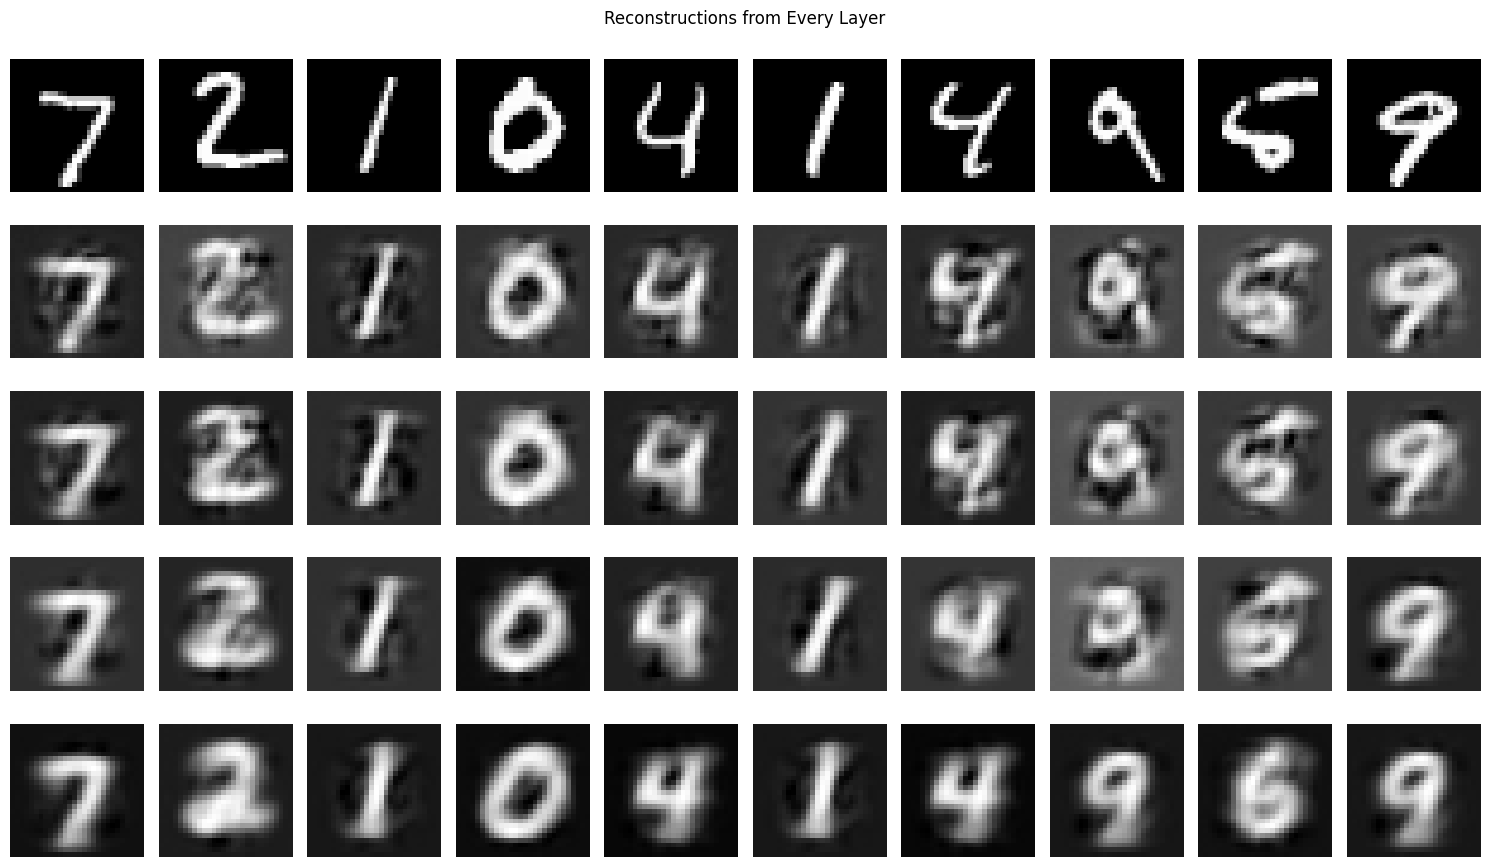

In [6]:
x, activations, reconstructions = visualize_reconstructions_general(
    model=model,
    dataset=test_loader,   # DataLoader
    sm=True,
    device=model.device,
    n_samples=10,
    save=False,
    dir="plots/",
    filename="reconstructions.png"
)

In [7]:
pixel_mean, pixel_std = compute_mnist_pixel_stats()

In [8]:
@torch.no_grad()
def generate_samples(model, target_activity, init_input=None, batch_size=10, tmax=500, pixel_std=None, pixel_mean=None, thresholds=[0.1, 0.1, 0.001]):
    """
    Generate samples by running DFC dynamics in reverse.

    Update order per timestep:
        start at output layer and move downward
        for each layer:
            1) update controller of that layer
            2) update activity of that layer
            3) continue to next lower layer
    """
    # === Setup ===
    model.targets = target_activity
    model.bzs = target_activity.shape[0]
    scaled_sig = ScaledSigmoid()

    # Initialize input (random if none provided)
    if init_input is None:
        init_input_scaled = (
            torch.clamp(torch.randn(batch_size, 28 * 28, device=model.device)
            * pixel_std.flatten().to(model.device)
            + pixel_mean.flatten().to(model.device), -0.4242, 2.8215)
        )
        model.input = init_input_scaled
    else:
        model.input = init_input.to(model.device)

    layer_out_dims = [layer.weights.shape[0] for layer in model.layers]

    v_fb_current = [torch.zeros((model.bzs, lod), device=model.input.device) for lod in layer_out_dims]
    v_ff_current = [torch.zeros((model.bzs, lod), device=model.input.device) for lod in layer_out_dims]
    v_current = [torch.zeros((model.bzs, lod), device=model.input.device) for lod in layer_out_dims]
    r_current = [torch.zeros((model.bzs, lod), device=model.input.device) for lod in layer_out_dims]

    # One PI controller per layer
    u_current = [torch.zeros((model.bzs, lod), device=model.input.device) for lod in layer_out_dims]
    u_int_current = [torch.zeros((model.bzs, lod), device=model.input.device) for lod in layer_out_dims]

    # Forward init
    r_prev = model.input
    for i, layer in enumerate(model.layers):
        v_ff_current[i] = r_prev.mm(layer.weights.t()) + layer.bias.unsqueeze(0)
        v_current[i] = v_ff_current[i].clone()
        r_current[i] = layer.activation_fn(v_ff_current[i])
        r_prev = r_current[i]

    _ = model(model.input)

    diffs = []
    diffs2 = []
    diffs3 = []
    video = [model.input[12].clone()]
    rs_hist = [model.layers[-1].r[12].clone()]

    tau = model.dt / model.time_constant_ratio
    n_layers = len(model.layers)

    converged_all_mask = torch.zeros(batch_size, dtype=torch.bool, device=model.input.device)

    # Simulate tmax timesteps
    for t_step in range(tmax - 1):
        # store updated controllers for this step
        u_next = [u.clone() for u in u_current]
        u_int_next = [u.clone() for u in u_int_current]

        # convergence mask for every controller
        converged_mask_per_layer = [None] * n_layers

        # Iterate from output layer down to first hidden layer
        for i in reversed(range(n_layers)):
            layer = model.layers[i]

            # --- 1) Update controller for this layer ---
            if i != n_layers - 1:
                error_i = model._compute_error_mse(
                    layer.activation_fn(v_ff_current[i]),
                    r_current[i]
                )
            else:
                error_i = model._compute_error(r_current[i], model.targets)
            u_int_next[i] = u_int_current[i] + model.dt * (error_i - model.alpha * u_current[i])
            u_next[i] = u_int_next[i] + model.k_p * error_i 


            converged_mask_per_layer[i] = torch.abs(error_i).mean(dim=1) < thresholds[i]
            

            # --- 2) Update activity for this layer ---
            r_prev = r_current[i - 1] if i != 0 else model.input

            # Basal update
            v_ff_current[i] += (
                r_prev.mm(layer.weights.t()) + layer.bias.unsqueeze(0) - v_ff_current[i]
            )
            v_ff_current[i] = v_ff_current[i].clone().detach()

            # Apical / soma update
            if i != n_layers - 1:
                v_fb_current[i] = (model.feedback_layers[i + 1](u_next[i + 1]))#*  layer.activation_derivative(v_ff_current[i])
                #v_fb_current[i] = (u_next[i + 1])@model.layers[i+1].weights *  layer.activation_derivative(v_ff_current[i])
                v_current[i] += tau * (v_fb_current[i] * (~converged_mask_per_layer[i + 1].unsqueeze(1)) + v_ff_current[i] - v_current[i] - u_next[i]* (~converged_mask_per_layer[i].unsqueeze(1)))#* (~converged_all_mask.unsqueeze(1))
                #v_current[i] += tau * (v_fb_current[i]  + v_ff_current[i] - v_current[i])
            else:
                v_current[i] += tau * (v_ff_current[i] - v_current[i]) # (~converged_all_mask.unsqueeze(1))

            r_current[i] = layer.activation_fn(v_current[i])

            layer.v_ff = v_current[i]
            layer.r = r_current[i]

        
        # Commit controller updates after full downward sweep
        u_int_current = u_int_next
        u_current = u_next

        converged_all_mask = torch.stack(converged_mask_per_layer, dim=0).all(dim=0)

        # Input update
        grad_input = model.feedback_layers[0](model.layers[0].activation_fn(v_ff_current[0])) 
        
        #grad_input = (v_ff_current[0])@torch.linalg.pinv(model.layers[0].weights).t()
        #grad_input += (u_next[0]@model.feedback_layers[0].weights.t()) 
        grad_input += model.feedback_layers[0](u_next[0]) 
        #grad_input = (u_next[0])@torch.linalg.pinv(model.layers[0].weights).t()
        #grad_input = torch.clamp(grad_input, -0.4242, 2.8215)
        #grad_input = scaled_sig(grad_input)

        model.input += tau * (grad_input - torch.abs(model.input)) #* (~converged_all_mask.unsqueeze(1))
        #model.input = grad_input 
        model.input = torch.clamp(model.input, -0.4242, 2.8215)

        video.append(model.input[12].clone())
        rs_hist.append(model.layers[-1].r[12].clone())

        diff = torch.abs(
            r_current[0] - model.layers[0].activation_fn(v_ff_current[0])
        ).mean().detach().cpu().numpy()
        diffs.append(diff)

        if len(model.layers) > 1:
            diff2 = torch.abs(
                r_current[1] - model.layers[1].activation_fn(v_ff_current[1])
            ).mean().detach().cpu().numpy()
            diffs2.append(diff2)
        
        if len(model.layers) > 2:
            diff3 = torch.abs(
                r_current[2] - model.layers[2].activation_fn(v_ff_current[2])
            ).mean().detach().cpu().numpy()
            diffs3.append(diff3)


    # === Collect steady-state representations ===
    rs = [model.input]
    for i, layer in enumerate(model.layers):
        layer.r = r_current[i]
        layer.r_ff = layer.activation_fn(v_ff_current[i])
        layer.r_prev = rs[i]
        rs.append(r_current[i])

    print(converged_mask_per_layer[-1].sum())

    generated_inputs = model.input

    if len(diffs) > 0:
        print(diffs[-1])
    if len(diffs2) > 0:
        print(diffs2[-1])
    if len(diffs3) > 0:
        print(diffs3[-1])

    return generated_inputs, rs, video, diffs, diffs2, diffs3, rs_hist

In [77]:
batch_size = 100
num_classes = 10

# Create one-hot targets for classes 0..9
target = torch.eye(num_classes).repeat_interleave(int(batch_size/10), dim=0)
#target = random_smooth_labels(targets=target.argmax(dim=1))

generated_input, rs, video, diffs,diffs2, diffs3, rs_hist = generate_samples(model, target, batch_size=batch_size, tmax=1000, pixel_mean=pixel_mean, pixel_std=pixel_std, thresholds=[0.01, 0.01, 0.01, 0.01])
print((target.argmax(dim=1)==rs[-1].argmax(dim=1)).sum())
print((target.argmax(dim=1)== model(generated_input).argmax(dim=1)).sum())

tensor(99, device='cuda:0')
0.0003970279
0.0005512509
0.0011436471
tensor(100, device='cuda:0')
tensor(100, device='cuda:0')


In [ ]:
batch_size = 100
num_classes = 10

target = torch.eye(num_classes).repeat_interleave(int(batch_size/10), dim=0)

init_input = 2 * torch.rand(batch_size, 200, device=model.device) - 1
init_input = torch.clamp(model.feedback_layers[0](init_input), -0.4242, 2.8215)

generated_input3, rs, video3, diffs,diffs2, diffs3, rs_hist = generate_samples(model, target, batch_size=batch_size, tmax=5000, init_input=init_input, thresholds=[0.1, 0.1, 0.1, 0.1])
print((target.argmax(dim=1)==rs[-1].argmax(dim=1)).sum())
print((target.argmax(dim=1)== model(generated_input3).argmax(dim=1)).sum())

In [66]:
batch_size = 100
num_classes = 10

Xs = []
Ys = []
Y_preds = []

for batch in train_loader:
    x = batch[0].to(model.device)
    y = batch[1].to(model.device)

    ypred = model(x)
    B, K = ypred.shape   # use model output size

    # true class indices
    top1 = y.argmax(dim=1)   # (B,)

    # sample a random class different from top1
    rand = torch.randint(0, K - 1, (B,), device=model.device)
    rand = rand + (rand >= top1).long()


    Y_preds.append(rand)
    Xs.append(batch[0])
    Ys.append(batch[1])

    if batch_size == 100:
        break

X = torch.cat(Xs, dim=0)
Y = torch.cat(Ys, dim=0)
Y_label = torch.argmax(Y, dim=1)
target2 = torch.cat(Y_preds,dim=0)
target2 = F.one_hot(torch.tensor(target2), num_classes=num_classes)

print("random targets generated ...")

generated_input2, rs, video2, diffs_2, diffs2_2, diffs3_2, rs_hist = generate_samples(
    model,
    target2,
    batch_size=batch_size,
    tmax=1000,
    init_input=X.to(model.device),
    thresholds=[0.1, 0.1, 0.1, 0.1],
)

print((target2.argmax(dim=1) == rs[-1].argmax(dim=1)).sum())
print((target2.argmax(dim=1) == model(generated_input2).argmax(dim=1)).sum())

random targets generated ...
tensor(99, device='cuda:0')
0.001550564
0.002363454
0.006971043
tensor(99, device='cuda:0')
tensor(98, device='cuda:0')


In [52]:
# convert one-hot target to class indices
target_labels = target2.argmax(dim=1)   # (N,)

# get sorting indices
sorted_idx = torch.argsort(target_labels)

# reorder everything
generated_input2 = generated_input2[sorted_idx]
target2 = target2[sorted_idx]

# (optional) also sort other outputs if needed
rs_sorted = [r[sorted_idx] for r in rs]  # if rs is a list of tensors

In [178]:
mean = generated_input.mean()
std = generated_input.std() + 1e-8

generated_input = (generated_input - mean) / std

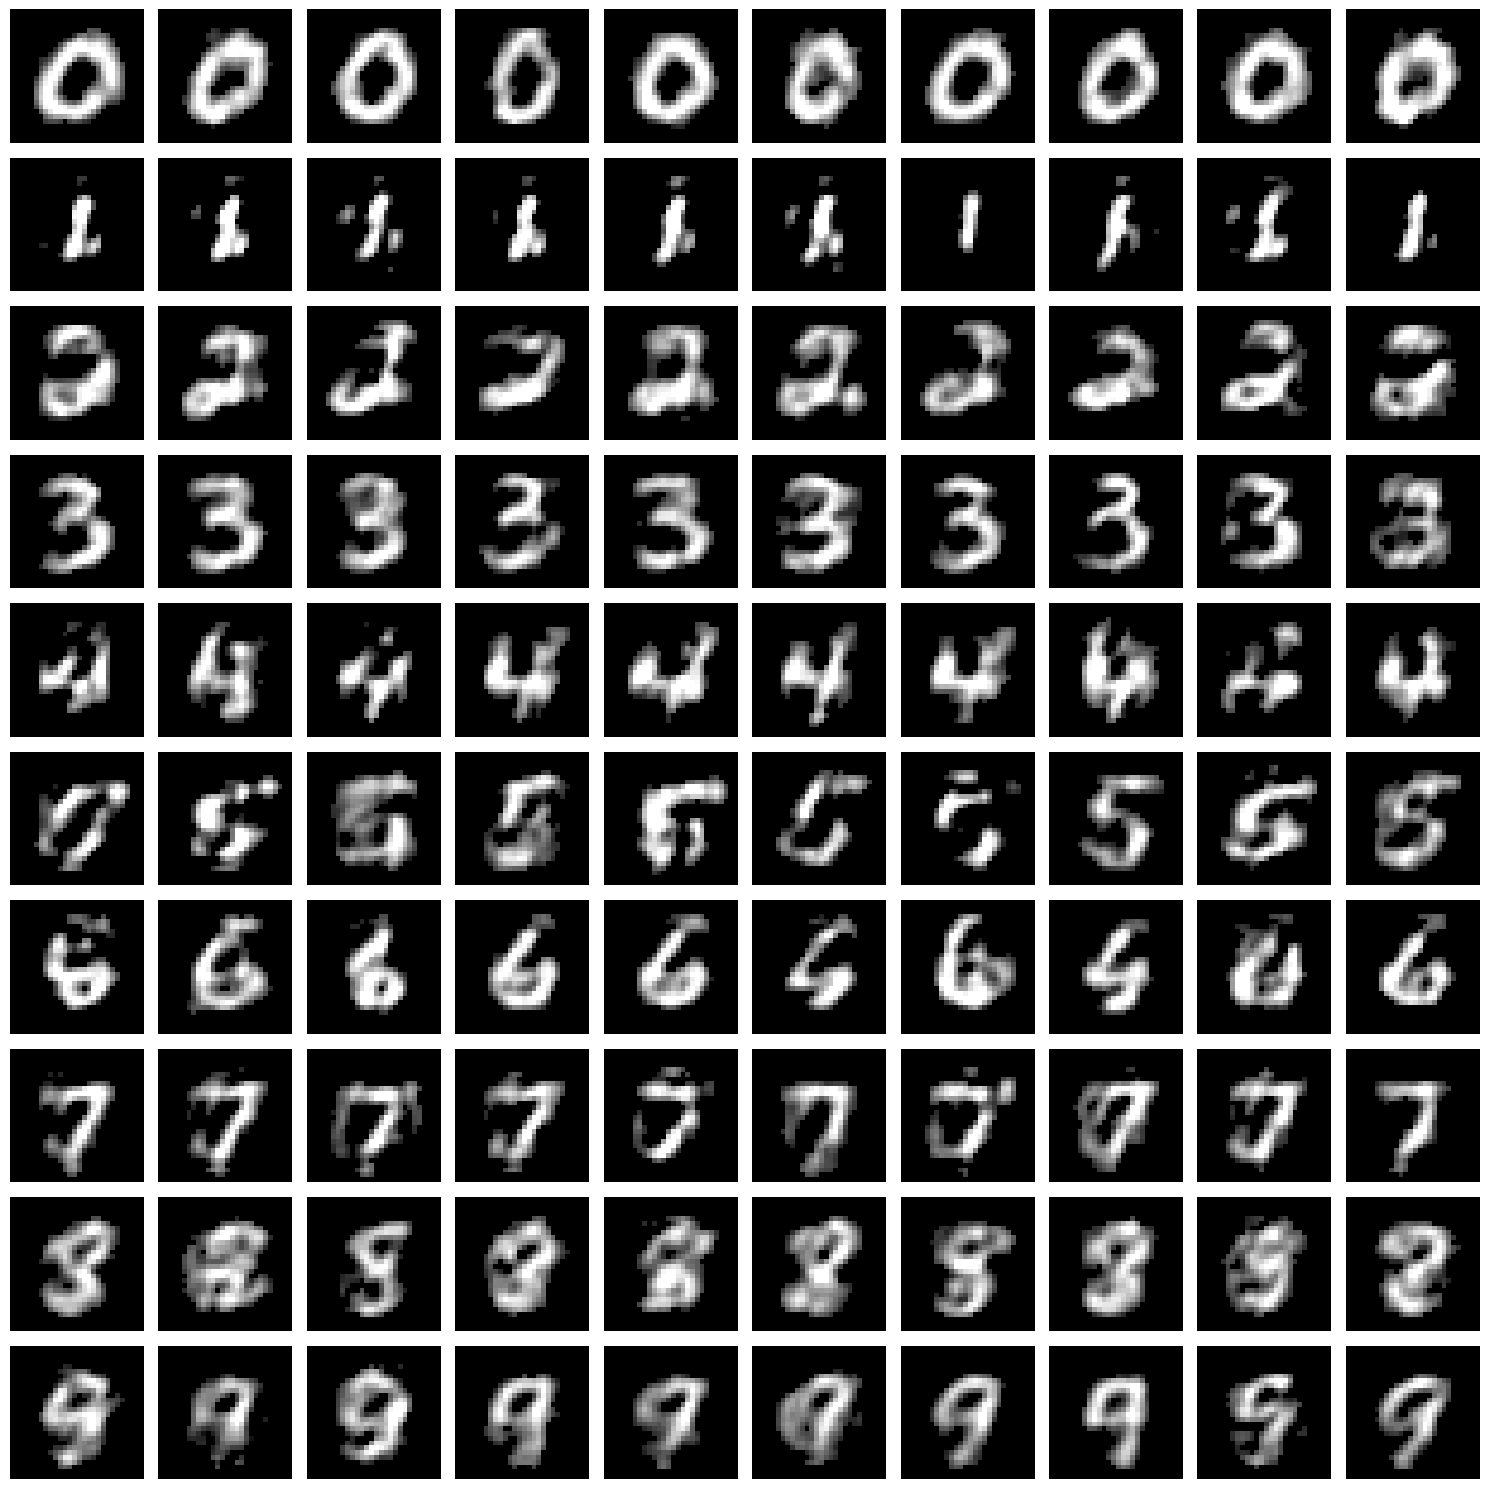

In [78]:
imgs = generated_input.detach().cpu()
n_cols=10

# Normalize to [0, 1] for display
#imgs = (imgs - imgs.min()) / (imgs.max() - imgs.min() + 1e-8)

# Try to infer image dimensions (e.g. 28x28 for MNIST)
img_size = int(imgs.shape[1] ** 0.5)
imgs = imgs.view(-1, img_size, img_size)

n_samples = imgs.shape[0]
n_rows = (n_samples + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 1.5, n_rows * 1.5))
for i in range(n_samples):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.imshow(imgs[i], cmap="gray", vmin=-0.4242, vmax=2.8215)
    #plt.imshow(imgs[i], cmap="gray", vmin=0, vmax=1)
    #plt.imshow(imgs[i], cmap="gray")
    plt.axis("off")
    if i ==100:
        break

plt.tight_layout()

plt.show()


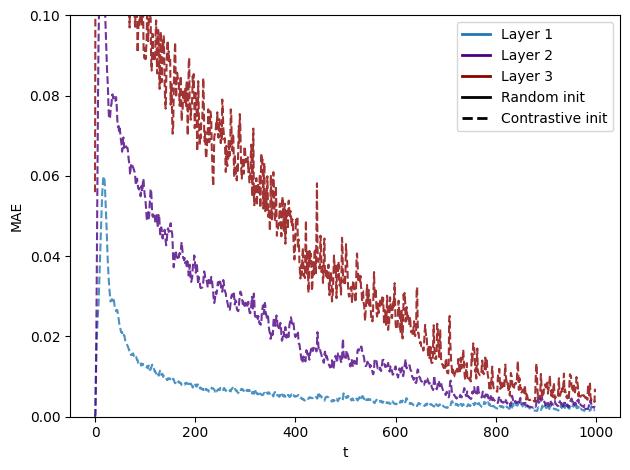

In [68]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Darker colors
colors = {
    "layer1": "#1f77b4",  # dark blue
    "layer2": "#4b0082",  # indigo (darker purple)
    "layer3": "#8b0000",  # dark red
}

"""# Solid lines (first dataset)
plt.plot(diffs,  alpha=0.8, color=colors["layer1"])
plt.plot(diffs2, alpha=0.8, color=colors["layer2"])
plt.plot(diffs3, alpha=0.8, color=colors["layer3"])"""

# Dashed lines (second dataset)
plt.plot(diffs_2,  alpha=0.8, color=colors["layer1"], linestyle="--")
plt.plot(diffs2_2, alpha=0.8, color=colors["layer2"], linestyle="--")
plt.plot(diffs3_2, alpha=0.8, color=colors["layer3"], linestyle="--")

plt.ylim([0, 0.1])
plt.xlabel("t")
plt.ylabel("MAE")

# Custom legend
legend_elements = [
    Line2D([0], [0], color=colors["layer1"], lw=2, label="Layer 1"),
    Line2D([0], [0], color=colors["layer2"], lw=2, label="Layer 2"),
    Line2D([0], [0], color=colors["layer3"], lw=2, label="Layer 3"),
    Line2D([0], [0], color="black", lw=2, linestyle="-", label="Random init"),
    Line2D([0], [0], color="black", lw=2, linestyle="--", label="Contrastive init"),
]

plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

In [ ]:
plot_receptive_fields(model, normalize=True)

In [ ]:
plt.imshow(video[4000].cpu().reshape(28,28),cmap="grey",  vmin=-0.4242, vmax=2.8215)
plt.axis("off")
plt.show()

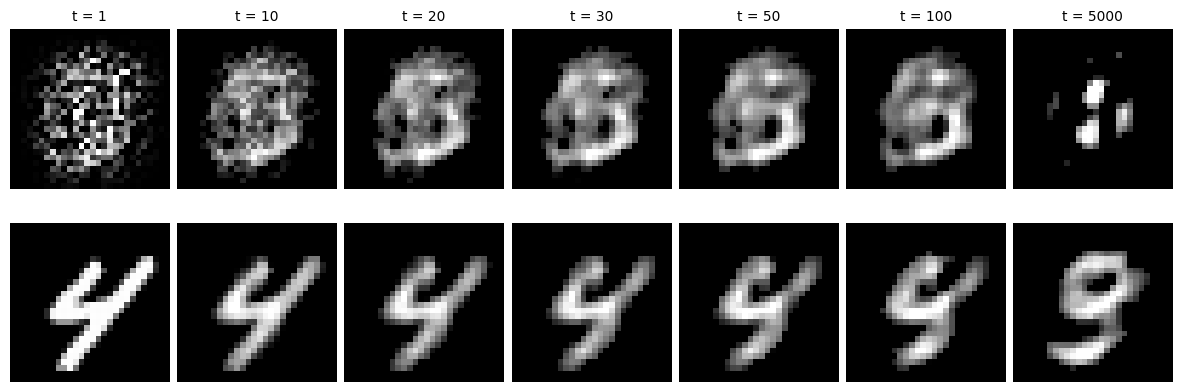

In [16]:

inds = [0,9,19,29,49,99,4999]
fig, axes = plt.subplots(2, len(inds), figsize=(15, 5))
for i in range(len(inds)):
    # First row
    axes[0,i].imshow(video[inds[i]].reshape(28,28).cpu(), cmap="gray")
    axes[0,i].axis("off")
    axes[0,i].set_title(f"t = {inds[i]+1}", fontsize=10)
    axes[1,i].imshow(video2[inds[i]].reshape(28,28).cpu(), cmap="gray")
    axes[1,i].axis("off")


# Reduce horizontal spacing
plt.subplots_adjust(wspace=0.05, hspace=0.01)

#plt.tight_layout()
plt.show()

In [170]:
print(torch.softmax(rs_hist[-1].reshape(1,10),dim=1))

tensor([[0.0017, 0.0019, 0.0034, 0.9512, 0.0022, 0.0275, 0.0016, 0.0029, 0.0055,
         0.0021]], device='cuda:0')


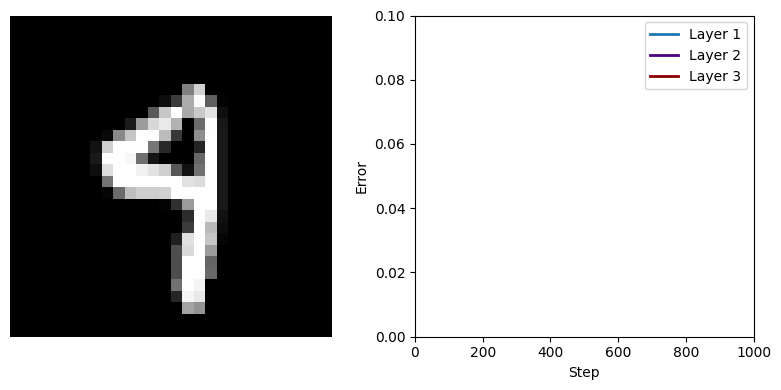

In [69]:
from matplotlib import pyplot as plt
from matplotlib import animation

# Darker colors
colors = {
    "layer1": "#1f77b4",  # dark blue
    "layer2": "#4b0082",  # indigo (darker purple)
    "layer3": "#8b0000",  # dark red
}

fig, (ax_img, ax_plot) = plt.subplots(1, 2, figsize=(8, 4))

# --- Image setup ---
im = ax_img.imshow(video2[0].cpu().reshape(28, 28),
                   cmap="grey", vmin=-0.4242, vmax=2.8215)
ax_img.axis("off")

# --- Line plot setup ---
line, = ax_plot.plot([], [], lw=2,  alpha=0.8, color=colors["layer1"], )
line2, = ax_plot.plot([], [], lw=2,  alpha=0.8, color=colors["layer2"], )
line3, = ax_plot.plot([], [], lw=2,  alpha=0.8, color=colors["layer3"], )
ax_plot.set_xlim(0, 1000)
ax_plot.set_ylim(0, 0.1)
ax_plot.set_xlabel("Step")
ax_plot.set_ylabel("Error")

# Custom legend
legend_elements = [
    Line2D([0], [0], color=colors["layer1"], lw=2, label="Layer 1"),
    Line2D([0], [0], color=colors["layer2"], lw=2, label="Layer 2"),
    Line2D([0], [0], color=colors["layer3"], lw=2, label="Layer 3"),
]

ax_plot.legend(handles=legend_elements)

xdata, ydata = [], []
xdata2, ydata2 = [], []
xdata3, ydata3 = [], []

def update(i):
    idx = i * 10

    # Update image
    im.set_array(video2[idx].cpu().reshape(28, 28))

    # Update line plot
    xdata.append(idx)
    ydata.append(diffs_2[idx])
    xdata2.append(idx)
    ydata2.append(diffs2_2[idx])
    xdata3.append(idx)
    ydata3.append(diffs3_2[idx])
    line.set_data(xdata, ydata)
    line2.set_data(xdata2, ydata2)
    line3.set_data(xdata3, ydata3)

    return [im, line, line2, line3]

ani = animation.FuncAnimation(
    fig,
    update,
    frames=100,
    interval=50
)

plt.tight_layout()
plt.show()

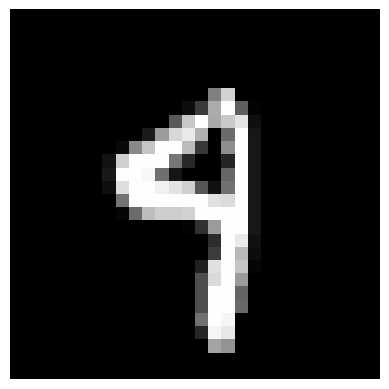

In [71]:
from matplotlib import animation


fig = plt.figure()
im = plt.imshow(video2[0].cpu().reshape(28,28),cmap="grey",  vmin=-0.4242, vmax=2.8215)
plt.axis("off")

def update(i):

    im.set_array(video2[i*10].cpu().reshape(28,28))
    return [im]

ani = animation.FuncAnimation(fig, update, frames=100, interval=50)


In [72]:

ani.save('morphing_animations/diagnostic.gif', writer='pillow', fps=5)

Animation.save using <class 'matplotlib.animation.PillowWriter'>


In [56]:
from torch.utils.data import TensorDataset, ConcatDataset, DataLoader
from torchvision import datasets, transforms

sm = torch.nn.Softmax(dim=1)

x_gen =  generated_input2.clone().detach().cpu()
#y_hat = sm(rs[-1]) 
y_hat = (sm(model(generated_input2)).clone().detach())#.argmax(dim=1)
#y_hat = F.one_hot(y_hat, num_classes=10).float()
#y_hat = target.float()

generated_dataset1 = TensorDataset(x_gen, y_hat)

# Original MNIST
"""from torchvision.datasets import MNIST
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])

mnist_train = datasets.MNIST(root="./data", train=True, download=True, transform=transform, target_transform=lambda y: F.one_hot(torch.tensor(y), num_classes=10).float())"""

# Combine them
full_dataset = ConcatDataset([generated_dataset1])

# Build dataloader
g = torch.Generator(device="cuda")
g.manual_seed(42)

train_loader2 = DataLoader(
    full_dataset,
    batch_size=100,
    shuffle=True,
    generator=g
)


In [57]:
# Train model
config2 = config.copy()
config2["epochs"] = 50
config2["layers"] = [784,200,200,200,10]
config2["loss_fn"] = "ce"
config2["save"] = False
config2 = dotdict(config2)
model2 = BP_network(config=config2)

"""trainer2 = Trainer(model2, train_loader, test_loader, config)
trainer2.train()"""
trainer3 = Trainer(model2, train_loader2, test_loader, config2)
trainer3.train()


Training:
 - layers: [784, 200, 200, 200, 10]
 - num_classes: 10
 - lr: 0.0001
 - lr_fb: 0.0001
 - batch_size: 100
 - batch_size_gen: 30000
 - epochs: 50
 - mode: di
 - num_workers: 0
 - loss_fn: ce
 - optimizer: Adam
 - scheduler: CosineAnnealingLR
 - activation_fun: Tanh
 - device: cuda
 - output_dir: ./outputs
 - seed: 1337
 - taus: [0.02, 0.02, 0.02, 0.016, 0.01]
 - target_lr: 1
 - alpha_di: 0.0017
 - dt_di: 0.02
 - time_constant_ratio: 0.2
 - tmax_di: 10
 - k_p: 2.0
 - eps: 0.0001
 - save: False
 - flatten_imgs: default
 - num_tasks: 2
 - classes_per_task: 5
 - setting: full
 - first_task_only: False
 - in_channels: 1
 - model: BP_network



Training epoch 001/50:   0%|          | 0/600 [00:00<?, ?batch/s]

				Epoch: 001, Train loss: 0.2516 & test loss: 0.4691 & accuracy: 85.25


				Epoch: 002, Train loss: 0.0925 & test loss: 0.4156 & accuracy: 87.36


				Epoch: 003, Train loss: 0.0838 & test loss: 0.3873 & accuracy: 88.33


...

				Epoch: 046, Train loss: 0.0640 & test loss: 0.1697 & accuracy: 94.66


				Epoch: 047, Train loss: 0.0639 & test loss: 0.1751 & accuracy: 94.67


				Epoch: 048, Train loss: 0.0639 & test loss: 0.1758 & accuracy: 94.46


				Epoch: 049, Train loss: 0.0639 & test loss: 0.1724 & accuracy: 94.63


				Epoch: 050, Train loss: 0.0638 & test loss: 0.1724 & accuracy: 94.53


In [58]:
import joblib
from tqdm import tqdm


# --- 1. Load MNIST ---
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # flatten 28x28 -> 784
])
mnist_train = datasets.MNIST(root="./data", train=True, transform=transform, download=True)

# Convert entire dataset to tensors
X = torch.stack([mnist_train[i][0] for i in tqdm(range(len(mnist_train)), desc="Loading MNIST")])
y = torch.tensor([mnist_train[i][1] for i in range(len(mnist_train))])

# Load UMAP model
reducer = joblib.load("umap_model.pkl")

# Load embedding
embedding = np.load("mnist_umap_embedding.npy")

Loading MNIST: 100%|██████████| 60000/60000 [00:06<00:00, 9659.53it/s] 


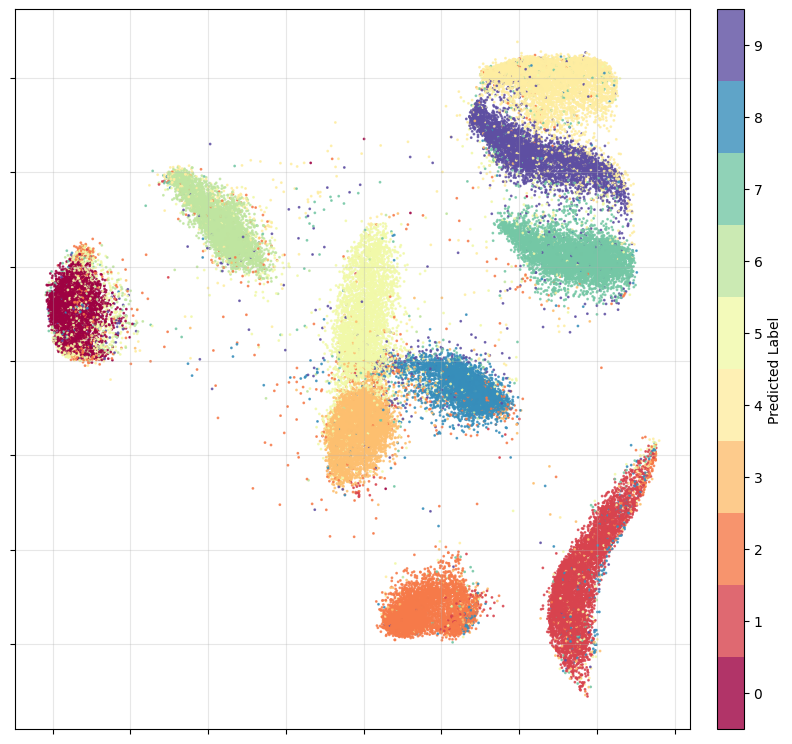

In [59]:
"""x_final = generated_input2.clone().detach().cpu()
sm = torch.nn.Softmax(dim=1)
y_hat = sm(model(generated_input2))
y_labels = torch.argmax(y_hat, dim=1)

embedding_gen = reducer.transform(x_final.numpy())
print("Generated embedding shape:", embedding_gen.shape)
"""
# --- Plot ---
fig = plt.figure(figsize=(9, 9))

# Main plot axis (fixed size)
ax = fig.add_axes([0.1, 0.1, 0.75, 0.8])

# Reserved space for colorbar (always exists!)
cax = fig.add_axes([0.88, 0.1, 0.03, 0.8])

# Plot generated samples
scatter_gen = ax.scatter(
    embedding_gen[:, 0], embedding_gen[:, 1],
    c=y_labels.cpu(), cmap="Spectral", s=1, alpha=0.8, label="Generated"
)

"""scatter_mnist = ax.scatter(
    embedding[:, 0], embedding[:, 1],
    c=y.cpu(), cmap="Spectral", s=1, alpha=0.8, label="MNIST"
)"""


# Remove tick labels
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.grid(True, alpha=0.3)

# Toggle this flag
use_colorbar = True

if use_colorbar:
    cbar = plt.colorbar(
        scatter_gen,
        cax=cax,
        boundaries=np.arange(11) - 0.5,
        ticks=np.arange(10)
    )
    cbar.set_label("Predicted Label")
else:
    # Keep layout identical, just hide colorbar axis
    cax.axis("off")

plt.show()

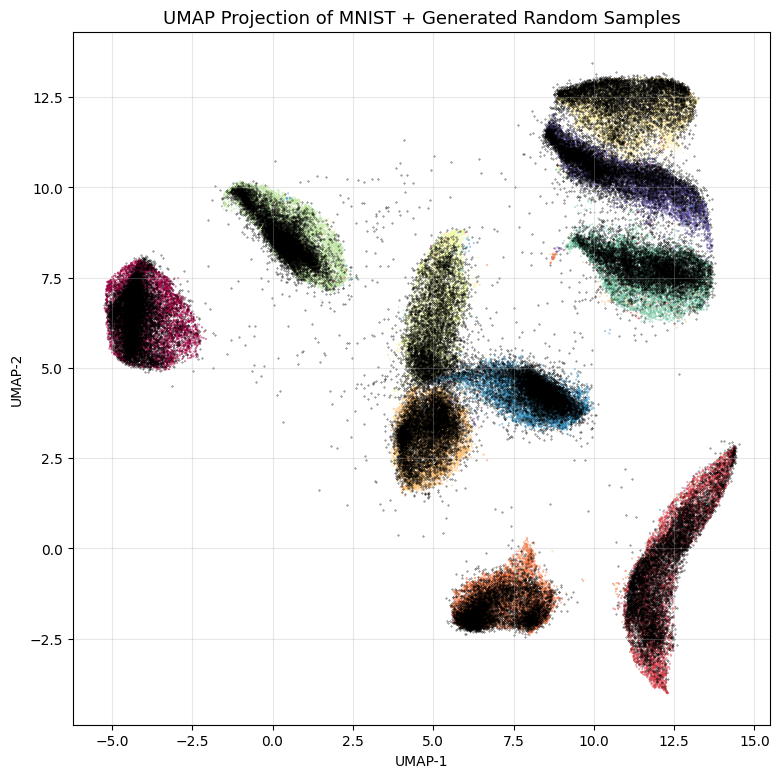

In [60]:
# --- Plot ---
plt.figure(figsize=(9, 9))

# Plot MNIST samples
scatter_mnist = plt.scatter(
    embedding[:, 0], embedding[:, 1],
    c=y.cpu(), cmap="Spectral", s=0.1, alpha=0.8, label="MNIST"
)

# Plot generated samples
scatter_gen = plt.scatter(
    embedding_gen[:, 0], embedding_gen[:, 1],
    c="black", s=0.1, alpha=0.8, label="Generated"
)

plt.title("UMAP Projection of MNIST + Generated Random Samples", fontsize=13)
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.grid(True, alpha=0.3)

# Choose which scatter to colorbar — here, the generated one
#cbar.set_label("Predicted Label")

plt.show()


In [ ]:
#layer = model.layers[0]
layer = model.feedback_layers[0]

#W = torch.linalg.pinv(layer.weights).t().detach().cpu()  # shape (out_dim, in_dim)
W = layer.weights.t().detach().cpu()
print(W.shape)
n_rows = 8
n_cols = 8
n_units = min(n_rows * n_cols, W.shape[0])
img_size = int(W.shape[1] ** 0.5)  # assume square input, e.g. 28x28 for MNIST

plt.figure(figsize=(1.5 * n_cols, 1.5 * n_rows))
for i in range(n_units):
    rf = W[i].view(img_size, img_size)

    plt.subplot(n_rows, n_cols, i + 1)
    plt.imshow(rf, cmap="gray")
    plt.axis("off")

plt.suptitle(f"Receptive Fields - Layer {0}", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchmetrics.image.fid import FrechetInceptionDistance


def _prepare_batch_for_fid(
    x: torch.Tensor,
    mean: float = 0.1307,
    std: float = 0.3081,
    flattened: bool = True,
    image_size: tuple = (28, 28),
) -> torch.Tensor:
    """
    Prepare a batch for Inception-based FID.

    Input can be:
      - [B, 784] for flattened grayscale MNIST
      - [B, H, W]
      - [B, 1, H, W]
      - [B, 3, H, W]

    Assumes the input is normalized with:
        x_norm = (x - mean) / std

    Returns:
        Tensor of shape [B, 3, H, W], float32, values in [0, 1]
    """
    if not isinstance(x, torch.Tensor):
        x = torch.as_tensor(x)

    x = x.float()

    # Case 1: flattened images [B, 784]
    if x.ndim == 2:
        if not flattened:
            raise ValueError(f"Got flattened input of shape {tuple(x.shape)}, but flattened=False")
        h, w = image_size
        if x.shape[1] != h * w:
            raise ValueError(f"Expected flattened dimension {h*w}, got {x.shape[1]}")
        x = x.view(x.shape[0], 1, h, w)

    # Case 2: [B, H, W] -> [B, 1, H, W]
    elif x.ndim == 3:
        x = x.unsqueeze(1)

    # Case 3: already [B, C, H, W]
    elif x.ndim != 4:
        raise ValueError(f"Expected input with 2, 3, or 4 dims, got shape {tuple(x.shape)}")

    # Undo normalization: x = x_norm * std + mean
    x = x * std + mean

    # Clamp to valid image range
    x = x.clamp(0.0, 1.0)

    # Convert grayscale to 3 channels
    if x.shape[1] == 1:
        x = x.repeat(1, 3, 1, 1)
    elif x.shape[1] != 3:
        raise ValueError(f"Expected 1 or 3 channels, got {x.shape[1]}")

    return x


@torch.no_grad()
def compute_fid_between_dataloaders(
    loader_a: DataLoader,
    loader_b: DataLoader,
    device: str = "cuda" if torch.cuda.is_available() else "cpu",
    mean: float = 0.1307,
    std: float = 0.3081,
    flattened: bool = True,
    image_size: tuple = (28, 28),
) -> float:
    """
    Compute FID between two datasets exposed as DataLoaders.

    Assumes each batch is either:
      - images
      - (images, labels)
      - [images, labels]
    """
    fid = FrechetInceptionDistance(
        feature=2048,
        normalize=True,
        reset_real_features=True
    ).to(device)

    fid.set_dtype(torch.float64)

    for batch in loader_a:
        imgs = batch[0] if isinstance(batch, (tuple, list)) else batch
        imgs = _prepare_batch_for_fid(
            imgs,
            mean=mean,
            std=std,
            flattened=flattened,
            image_size=image_size
        ).to(device)
        fid.update(imgs, real=True)
        
    print("Train loader A done")

    for batch in loader_b:
        imgs = batch[0] if isinstance(batch, (tuple, list)) else batch
        imgs = _prepare_batch_for_fid(
            imgs,
            mean=mean,
            std=std,
            flattened=flattened,
            image_size=image_size
        ).to(device)
        fid.update(imgs, real=False)

    print("Train loader B done")
        

    score = fid.compute()
    return float(score.item())

In [63]:

fid_value = compute_fid_between_dataloaders(train_loader, train_loader2)
print(f"FID: {fid_value:.4f}")

Train loader A done
Train loader B done
FID: 86.6921


FID contrastive:

83.4253

FID random:

FID: 116.3866